In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib as mpl
from tqdm.notebook import tqdm
import pickle
from scipy.optimize import minimize
from skopt import gp_minimize
from itertools import combinations

import utils_string as uts
import utils as ut
import utils_phase_diagr as ut_pd

# String model with fixed time of maximum expansion and total abundance at memory time

### Genereting an ensemble of recruited binary clones at given string-model parameters

Use the script **string_model_gen_repertoire.py**

In [ ]:
out_dir_str = 'out_data/string_model/'
str_name = 'gamma=2.0_L=40'
mean_logtau, std_logtau = -4, 2.5

with open(out_dir_str + f'string_ens_{str_name}.pkl', 'rb') as f:
    string_ens = pickle.load(f)
pars = pd.read_csv(out_dir_str + f'string_pars_{str_name}.tsv', sep='\t', header=None, index_col=0)[1].to_dict()
string_model = uts.TT_string(N_tot=pars['N_tot'], L_string=int(pars['L_string']), N_recruit=pars['N_recruit'])

logtau_ens = []
for i, strings in enumerate(string_ens):
    h_dists = uts.comp_h_dist(strings, np.zeros(len(strings[0])))
    logtau_ens.append(string_model.get_logtau(h_dists, mean_logtau, std_logtau))

#### Checking some examples of trajectories given the generated strings

In [ ]:
alpha0, beta0, gamma = 1e-6, 1.049, 0.021

# Sampling taus from lognormal with default parameters
tau_samp = ut.tau_sampler_lognorm(logmean=mean_logtau, logstd=std_logtau)

# Defining the default realistic paramters
taus = np.exp(logtau_ens[np.random.randint(0, len(logtau_ens))])
TT_pars = ut.TT_params(taus, alpha0=alpha0, beta0=beta0, gamma=gamma)

# Integration parameters
traj_steps, dt = 50, 0.005
t_steps = int(30 / dt)

times, T_trajs, P_trajs, S_trajs = ut.run_setting(TT_pars, tau_samp, t_steps, dt, traj_steps=traj_steps)

extinct_traj = np.all(T_trajs <= 1, axis=0)
T_tot = np.sum(T_trajs[:,~extinct_traj], axis=1)
t_max = times[np.argmax(T_tot)]
T_mem = T_tot[-1]
print(t_max, T_tot.max(), T_mem)

0.001 1.5857492565404436 0.0016687596457902723
7.25 312.94307341068003 306.40883458096437


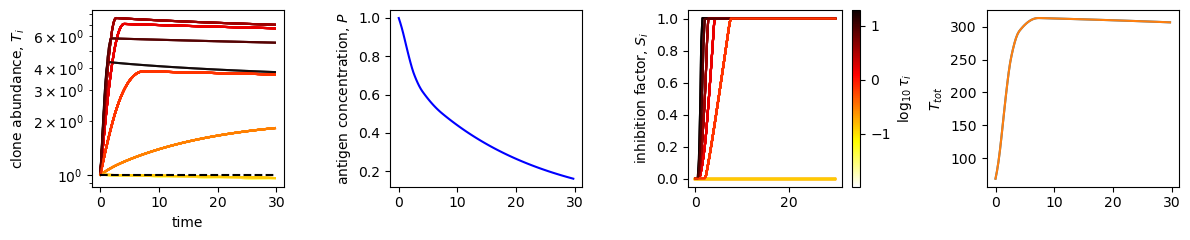

In [ ]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1,4,figsize=(12,2.5))

ax1.set_yscale('log')
ax1.set_xlabel('time')
ax1.set_ylabel(r'clone abundance, $T_i$')
cmap = mpl.colormaps.get_cmap('hot_r')
cmap_norm = plt.Normalize(vmin=min(np.log10(taus)), vmax=max(np.log10(taus)))
for i, Ts in enumerate(T_trajs.T):
    color = cmap(cmap_norm(np.log10(taus[i])))
    ax1.plot(times, Ts, c=color, alpha=0.8)
    
#ax1.set_ylim(0.9, np.max(T_trajs)*1.1)

#ax1.plot(times, T_tot, c='b', label=r'$\sum_i T_i$')
ax1.plot(times, np.ones(len(times)), c='k', ls='--')
#ax1.legend()

ax2.set_ylabel(r'antigen concentration, $P$')
ax2.plot(times, P_trajs, c='b')

ax3.set_ylabel(r'inhibition factor, $S_i$')
for i, Ss in enumerate(S_trajs.T):
    color = cmap(cmap_norm(np.log10(taus[i])))
    ax3.plot(times, Ss, c=color)
    
sm = plt.cm.ScalarMappable(cmap=cmap, norm=cmap_norm)
sm.set_array([])
fig.colorbar(sm, ax=ax3, label=r'$\log_{10} \tau_i$')

plt.plot(times, np.array(T_tot))
  
ax4.set_ylabel(r'$T_{tot}$')
min_t = np.argmin(T_trajs[-1])
ax4.plot(times, np.array(T_tot), label=r'$\sum T_i$')
#ax4.plot(times, np.array(T_tot)-100*T_trajs[:,min_t], label=r'$\sum T_i - N_{recr} * T_{min}$')
#ax4.legend()
plt.tight_layout()

### Computing beta0 at constant time of max expansion

In [2]:
def func_to_minimize(alpha0, beta0, gamma, logtau_ens, R, Tmem=300, tmax=9):

    ts, T_mems = [], []
    for _ in range(R):

        logtaus = logtau_ens[np.random.randint(0, len(logtau_ens))]
        pars = ut.TT_params(np.exp(logtaus), alpha0=alpha0, beta0=beta0, gamma=gamma)
        dt = 0.005
        t_steps = int(30 / dt)
        times, T_trajs, _, _ = ut.run_setting(pars, ut.tau_sampler_lognorm(), t_steps, 0.005, traj_steps=50)

        # Tricky computation of max expansion because of trajectories that get extinct (for low alpha0)
        # We remove from computation trajectories that were never above 1
        extinct_traj = np.all(T_trajs <= 1, axis=0)
        T_tot = np.sum(T_trajs[:,~extinct_traj], axis=1)
        ts.append(times[np.argmax(T_tot)])
        T_mems.append(T_tot[-1])

    return (np.mean(ts) - tmax)**2/tmax**2 + (np.mean(T_mems) - Tmem)**2/Tmem**2

#### Example of a landscape of the function that minimizes both Tmax at memory and tmax of expansion

In [81]:
out_dir_str = 'out_data/string_model/'
str_name = 'gamma=1.0_L=40'
mean_logtau, std_logtau = -4, 2.5

with open(out_dir_str + f'string_ens_{str_name}.pkl', 'rb') as f:
    string_ens = pickle.load(f)
pars = pd.read_csv(out_dir_str + f'string_pars_{str_name}.tsv', sep='\t', header=None, index_col=0)[1].to_dict()
string_model = uts.TT_string(N_tot=pars['N_tot'], L_string=int(pars['L_string']), N_recruit=pars['N_recruit'])

logtau_ens = []
for i, strings in enumerate(string_ens):
    h_dists = uts.comp_h_dist(strings, np.zeros(len(strings[0])))
    logtau_ens.append(string_model.get_logtau(h_dists, mean_logtau, std_logtau))

alpha0=1e-5
gammas = np.logspace(-3, -1, 10)
betas = np.logspace(-0.5, 1, 10)
result2 = np.zeros((len(gammas), len(betas)))
progress = tqdm(total=len(gammas)*len(betas))
for i, gamma in enumerate(gammas):
    for j, beta in enumerate(betas):
        result2[i,j] = func_to_minimize(alpha0, beta, gamma, logtau_ens, 5)
        progress.update(1)


  0%|          | 0/100 [00:00<?, ?it/s]

NameError: name 'func_to_minimize' is not defined

In [ ]:
func = lambda x: func_to_minimize(alpha0, 10**x[0], 10**x[1], logtau_ens, 15)
r = gp_minimize(func, x0=[0.5, -1.5], dimensions=[(-0.5, 1.0), (-3.25, -1.0)], n_calls=30)
print(r.x, r.fun)

[0.45226555125591006, -2.9724205159155237] 0.0015293184389836743


Text(0, 0.5, '$\\gamma$')

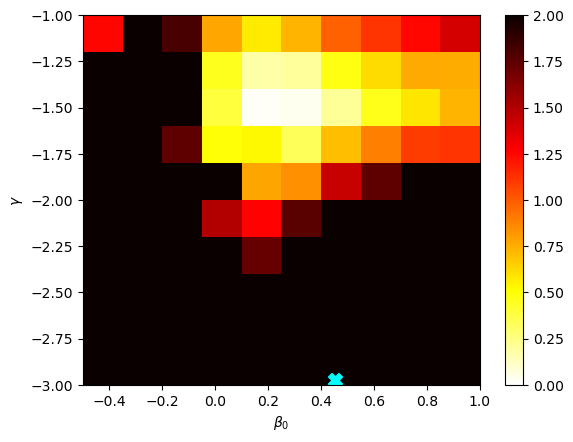

In [ ]:
plt.imshow(result2, extent=(np.log10(betas[0]), np.log10(betas[-1]), np.log10(gammas[0]), np.log10(gammas[-1])), 
           cmap='hot_r', vmin=0, vmax=2, aspect='auto', origin='lower')
cb = plt.colorbar()
plt.scatter(r.x[0], r.x[1], c='cyan', marker='X', s=100, label='Optimized parameters')
plt.xlabel(r'$\beta_0$')
plt.ylabel(r'$\gamma$')

#### Computing the best parameters to satisfy the constraints

In [ ]:
out_dir_str = 'out_data/string_model/'
str_name = 'gamma=1.0_L=40'
mean_logtau, std_logtau = -4, 2.5

with open(out_dir_str + f'string_ens_{str_name}.pkl', 'rb') as f:
    string_ens = pickle.load(f)
pars = pd.read_csv(out_dir_str + f'string_pars_{str_name}.tsv', sep='\t', header=None, index_col=0)[1].to_dict()
string_model = uts.TT_string(N_tot=pars['N_tot'], L_string=int(pars['L_string']), N_recruit=pars['N_recruit'])

logtau_ens = []
for i, strings in enumerate(string_ens):
    h_dists = uts.comp_h_dist(strings, np.zeros(len(strings[0])))
    logtau_ens.append(string_model.get_logtau(h_dists, mean_logtau, std_logtau))


alpha0s = np.logspace(-5.5, -3, 35)

results = []
progress = tqdm(total=len(alpha0s))
for alpha0 in alpha0s:
    func = lambda x: func_to_minimize(alpha0, 10**x[0], 10**x[1], logtau_ens, 15)
    r = gp_minimize(func, x0=[0.5, -1.5], dimensions=[(-0.5, 1.0), (-3.5, -1.0)], n_calls=35)
    results.append((10**r.x[0], 10**r.x[1], r.fun))
    print(alpha0, r.fun)
    progress.update(1)

out_dir = 'out_data/string_model_Tmax/'
name = str_name + f'_meanlt={mean_logtau}_stdlt={std_logtau}'
with open(out_dir + f'a0s_results_{name}.pkl', 'wb') as f:
    pickle.dump((alpha0s, results), f)

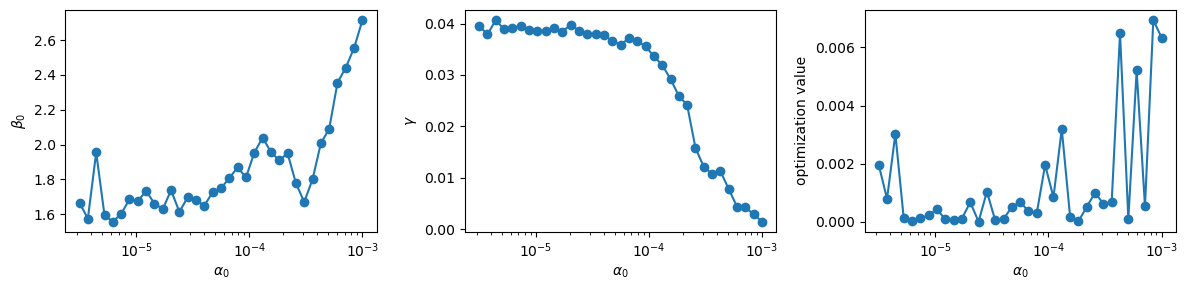

In [38]:
out_dir_str = 'out_data/string_model/'
str_name = 'gamma=1.0_L=40'
mean_logtau, std_logtau = -4, 2.5
out_dir = 'out_data/string_model_Tmax/'

name = str_name + f'_meanlt={mean_logtau}_stdlt={std_logtau}'
with open(out_dir + f'a0s_results_{name}.pkl', 'rb') as f:
    alpha0s, results = pickle.load(f)

    
fig, (ax1, ax2, ax3) = plt.subplots(1,3,figsize=(12,3))

for ax in [ax1, ax2, ax3]:
    ax.set_xscale('log')
    ax.set_xlabel(r'$\alpha_0$')

ax1.set_ylabel(r'$\beta_0$')
ax1.plot(alpha0s, [r[0] for r in results], marker='o')

ax2.set_ylabel(r'$\gamma$')
ax2.plot(alpha0s, [r[1] for r in results], marker='o')

ax3.set_ylabel(r'optimization value')
ax3.plot(alpha0s, [r[2] for r in results], marker='o')

plt.tight_layout()

### Analysis of the generated clonotype abundances and coverage

Use the script **string_model_gen_trajs.py**

In [14]:
n_runs = 2
out_dir_str = 'out_data/string_model/'
str_name = 'gamma=1.0_L=40'
out_dir = 'out_data/string_model_Tmax/'
name = str_name + '_meanlt=-4_stdlt=2.5'

with open(out_dir_str + f'string_ens_{str_name}.pkl', 'rb') as f:
    string_ens = pickle.load(f)

with open(out_dir + f'a0s_results_{name}.pkl', 'rb') as f:
    alpha0s, results = pickle.load(f)


Rt = 0
string_ids_ens, Ts_final_ens = [[] for _ in range(len(alpha0s))], [[] for _ in range(len(alpha0s))]
for i in range(n_runs):

    with open(out_dir + f'Ts_final_{name}_{i+1}.pkl', 'rb') as f:
        string_ids, Ts_final, _, _ = pickle.load(f)
    for j in range(len(alpha0s)):
        string_ids_ens[j].extend(string_ids[j])
        Ts_final_ens[j].extend(Ts_final[j])

    pars = pd.read_csv(out_dir + f'pars_{name}_{i+1}.tsv', sep='\t', header=None, index_col=0)[1].to_dict()
    Rt += int(pars['chunk_size'])
print(Rt)

L = int(pars['L_string'])
string_model = uts.TT_string(N_tot=pars['N_tot'], L_string=int(pars['L_string']), N_recruit=pars['N_recruit'])
hs_ens = [uts.comp_h_dist(strings, np.zeros(len(strings[0]))) for strings in string_ens]
mean_lt, std_lt = pars['mean_logtau'], pars['std_logtau']
logtau_ens = [string_model.get_logtau(hs, mean_lt, std_lt) for hs in hs_ens]

2000


In [15]:
n_muts = [0, 2, 4, 8, 12, 16, 20]
max_R_n_muts = 10

covers_min, covers_avh, covers_activ = [], [], []
T_tots, inv_simpss, richs = [], [], []
progress = tqdm(total=len(alpha0s))
for i in range(len(alpha0s)):

    strings = [string_ens[k] for k in string_ids_ens[i]]
    logtaus = [logtau_ens[k] for k in string_ids_ens[i]]
    covers_min_aux, covers_avh_aux, covers_activ_aux = [], [], []

    for n_mut in n_muts:

        cs_min_aux, cs_avh_aux, cs_activ_aux = [], [], []
        R_count = 0
        for mut_ids in combinations(np.arange(L), n_mut):

            a_mut = np.zeros(L)
            a_mut[list(mut_ids)] = 1
            h_dists = [uts.comp_h_dist(strings[k], a_mut) for k in range(Rt)]
            taus = [np.exp(string_model.get_logtau(hs, mean_lt, std_lt)) for hs in h_dists]
            cs_min_aux.extend([uts.compute_coverage_min(h_dists[k], pars['L_string'], Ts_final_ens[i][k]) for k in range(Rt)])
            cs_avh_aux.extend([uts.compute_coverage_avh(h_dists[k], pars['L_string'], Ts_final_ens[i][k]) for k in range(Rt)])
            #cs_activ_aux.extend([uts.compute_coverage_activ(taus[k], Ts_final_ens[i][k]) for k in range(Rt)])

            R_count += 1
            if R_count > max_R_n_muts:
                break

        covers_min_aux.append(np.mean(cs_min_aux))
        covers_avh_aux.append(np.mean(cs_avh_aux))
        #covers_activ_aux.append(np.mean(cs_activ_aux))

    covers_min.append(covers_min_aux)
    covers_avh.append(covers_avh_aux)
    #covers_activ.append(covers_activ_aux)

    T_tots.append(np.mean( [np.sum(Ts_final_ens[i][r]) for r in range(Rt)] ))
    inv_simpss.append(uts.compute_inv_simps(Ts_final_ens[i]))
    richs.append(uts.compute_richness(Ts_final_ens[i], strings))
    progress.update(1)
    
covers_min, covers_avh, covers_activ = np.array(covers_min), np.array(covers_avh), np.array(covers_activ)

  0%|          | 0/35 [00:00<?, ?it/s]

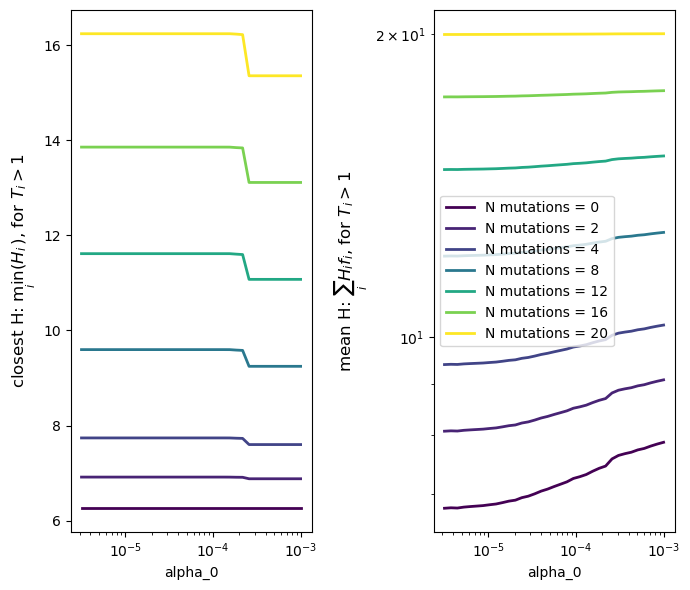

In [16]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(7, 6))
cmap = mpl.colormaps.get('viridis')

for ax in (ax1, ax2):
    ax.set_xscale('log')
    ax.set_xlabel('alpha_0')

ax2.set_yscale('log')

ax1.set_ylabel(r'closest H: $\min_i (H_i)$, for $T_i > 1$', fontsize=12)
ax2.set_ylabel(r'mean H: $\sum_i H_i f_i$, for $T_i > 1$', fontsize=12)
for i, n_mut in enumerate(n_muts):
    c = cmap(n_mut/max(n_muts))
    ax1.plot(alpha0s, covers_min[:,i], label=f'N mutations = {n_mut}', c=c, lw=2)
    ax2.plot(alpha0s, covers_avh[:,i], label=f'N mutations = {n_mut}', c=c, lw=2)
ax2.legend()

plt.tight_layout()
plt.savefig(f'plots/evo_model_coverage_Tmax/{name}_coverage.svg', facecolor='w')

In [17]:
max_n_mut = 10
max_R_n_muts = 10


covers_min = []
progress = tqdm(total=len(alpha0s))
for i in range(len(alpha0s)):
    strings = [string_ens[k] for k in string_ids_ens[i]]
    logtaus = [logtau_ens[k] for k in string_ids_ens[i]]
    covers_min_aux = []

    for n_mut in range(1, max_n_mut):

        cs_min_aux = []
        R_count = 0
        for mut_ids in combinations(np.arange(L), n_mut):

            a_mut = np.zeros(L)
            a_mut[list(mut_ids)] = 1
            h_dists = [uts.comp_h_dist(strings[k], a_mut) for k in range(Rt)]
            cs_min_aux.extend([uts.compute_coverage_min(h_dists[k], pars['L_string'], Ts_final_ens[i][k]) for k in range(Rt)])

            R_count += 1
            if R_count > max_R_n_muts:
                break

        covers_min_aux.append(np.mean(cs_min_aux))

    covers_min.append(covers_min_aux)
    progress.update(1)
    
covers_min = np.array(covers_min)

  0%|          | 0/35 [00:00<?, ?it/s]

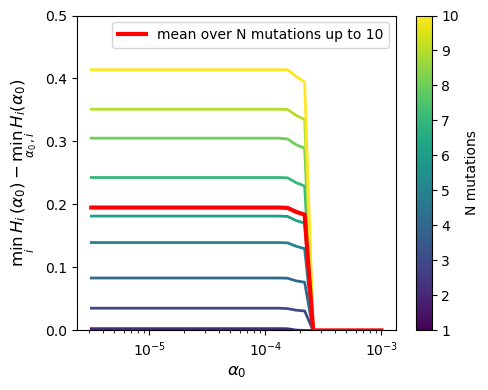

In [18]:
fig, ax = plt.subplots(1,1,figsize=(5,4))

cmap = mpl.colormaps.get('viridis')

ax.set_xscale('log')
ax.set_ylabel(r'$\min_i \, H_i(\alpha_0) - \min_{\alpha_0,i} \, H_i(\alpha_0)$', fontsize=12)
ax.set_xlabel(r'$\alpha_0$', fontsize=12)
for i, n_mut in enumerate(range(1,max_n_mut)):
    c = cmap(n_mut/(max_n_mut-1))
    norm = np.min(covers_min[:,i])
    ax.plot(alpha0s, covers_min[:,i]-norm, c=c, lw=2)

norms = np.min(covers_min[:,:max_n_mut], axis=0)
mean_h_min = np.mean(covers_min[:,:max_n_mut] - norms[np.newaxis,:], axis=1)
ax.plot(alpha0s, mean_h_min, label=f'mean over N mutations up to {max_n_mut}', c='r', lw=3)

norm_cb = plt.Normalize(vmin=1, vmax=max_n_mut)
cb = plt.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm_cb), label='N mutations', ax=ax)
plt.legend()
plt.ylim(0, 0.5)
plt.tight_layout()
plt.savefig(f'plots/evo_model_coverage_Tmax/{name}_coverage_rescaled.svg', facecolor='w')

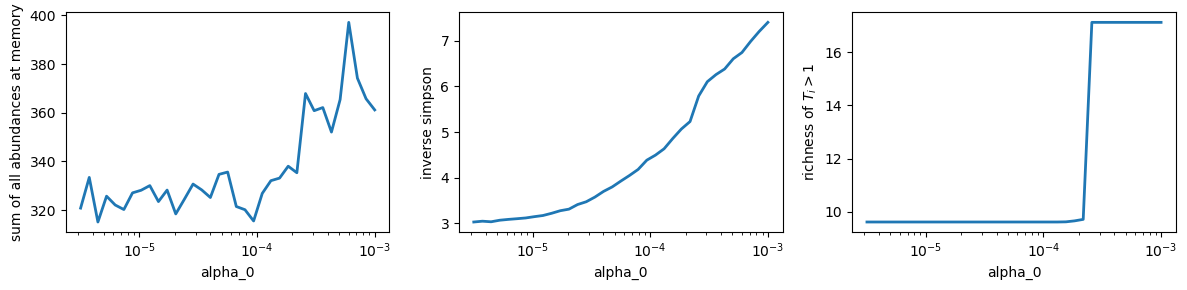

In [19]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12,3))

for ax in (ax1, ax2, ax3):
    ax.set_xscale('log')
    ax.set_xlabel('alpha_0')

ax1.set_ylabel('sum of all abundances at memory')
ax1.plot(alpha0s, np.array(T_tots), lw=2)
#ax1.set_ylim(1, max(factors)+0.2)

ax2.set_ylabel('inverse simpson')
ax2.plot(alpha0s, inv_simpss, lw=2)

ax3.set_ylabel('richness of $T_i>1$')
ax3.plot(alpha0s, richs, lw=2)

plt.tight_layout()
plt.savefig(f'plots/evo_model_coverage_Tmax/{name}_tradeoff.svg', facecolor='w')

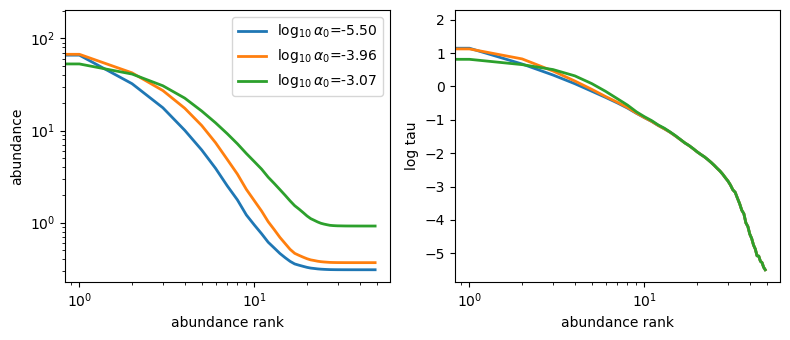

In [20]:
i_alphas = [0, 21, 33]
max_rank = 50

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.5))

ax1.set_xlabel('abundance rank')
ax1.set_ylabel('abundance')
ax1.set_yscale('log')
ax1.set_xscale('log')

ax2.set_xlabel('abundance rank')
ax2.set_ylabel('log tau')
ax2.set_xscale('log')

for i, i_alpha in enumerate(i_alphas):

    av_T_rank, av_lt_rank, T_rank_count = np.zeros(max_rank), np.zeros(max_rank),  np.zeros(max_rank)
    for r, Ts in enumerate(Ts_final_ens[i_alpha]):
        rank = np.argsort(Ts)[::-1][:min(len(Ts), max_rank)]
        av_T_rank += np.array(Ts[rank])
        av_lt_rank += np.array(logtau_ens[string_ids_ens[i_alpha][r]])[rank]
        T_rank_count += 1
    av_T_rank /= T_rank_count
    av_lt_rank /= T_rank_count

    lab = r'$\log_{10}\alpha_0$=%3.2f'%np.log10(alpha0s[i_alpha])
    ax1.plot(np.arange(max_rank), av_T_rank, label=lab, lw=2)
    ax2.plot(np.arange(max_rank), av_lt_rank, label=lab, lw=2)

ax1.legend()

plt.tight_layout()